In [399]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from statsmodels.stats.proportion import proportion_confint
from tqdm.notebook import tqdm as tqdm_notebook
from collections import namedtuple
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from tqdm.notebook import tqdm
from statsmodels.stats.proportion import proportion_confint
from scipy import stats

# Оценка Theta
- формула генерации данных
- формула и функция рассчета theta
- показать что при этом theta у нас наименьшая дисперсия Y cuped метрики в обоих группах

In [400]:
def generate_corr_data(N, pre_mean, post_mean, corr = 0.8):
    """Генерируем датафрейм с нужной корреляцией между 2 ковариатами.
    
    N - размер data frame
    pre_mean - средняя до старта теста
    post_mean - средняя после старта теста
    corr - корреляция метрики во время эксперимента с метрикой до эксперимента.
    Возвращает датафрейм с коррелированной метрикой до эксперимента и после эксперимента
    """
    cov = [[1, corr], [corr, 1]]
    correlated_data = np.random.multivariate_normal([pre_mean, post_mean], cov, N)
    correlated_df = pd.DataFrame({'post_value': correlated_data[:, 1], 'pre_value': correlated_data[:, 0]})
    return (correlated_df)

<Figure size 720x720 with 0 Axes>

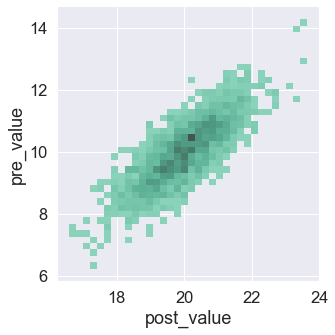

In [401]:
corr_data = generate_corr_data(2000, 10, 20, corr = 0.8)
plt.figure(figsize = (10, 10))
sns.displot(corr_data, x = "post_value", y = "pre_value")

In [402]:
corr_data

,post_value,pre_value
0,20.085653,9.826061
1,20.933937,10.089819
2,19.832923,9.977844
3,19.821900,8.862618
4,20.228221,10.633786
...,...,...
1995,20.326570,10.420073
1996,21.461309,10.250115
1997,20.215040,9.856462
1998,20.709096,9.440668


In [733]:
np.corrcoef(corr_data['post_value'], corr_data['pre_value'])[0, 1]

0.8027978882790924

# cuped test
- функция
- разовый прогон теста
- оценка мощности в сравнении с базовым ttest
- оценка стат значимости

# напишем функцию оценивающую Theta
Исходная функция новой метрики:
$${Y}_{cuped} = {Y} - \theta {X}$$
$$Y_{cuped\,full} = {Y} - \theta {X} + \theta\mathbb{E}X\,$$
где,

Y - наша целевая метрика после старта эксперимента

theta - специальный параметр, который нужно определить

X - преэкспериментальные данные, или ковариата скоррелированная с Y, но не испытающая воздействие нововедения

$$\theta\mathbb{E}X\ - математическое\;ожидание\;переменной\;X$$

Формула для оптимального значения $\theta$:
$$\theta\,\text{=}\,\frac{COV\left(Y,\,X\right)}{D\left(X\right)}$$

In [523]:
def calculate_theta_basic(pre, post):
    theta = (np.cov(post, pre)[0, 1]) /\
            (np.var(pre))
    return(theta) 
    
    
def calculate_theta_for_test(control_pre, control_post, test_pre, test_post):
    theta = (np.cov(control_post, control_pre)[0, 1] + np.cov(test_post, test_pre)[0, 1]) /\
            (np.var(control_pre) + np.var(test_pre))
    return(theta)

In [742]:
sample_size = 1000
df_control = generate_corr_data(sample_size, 10, 10, corr=0.8)
df_test = generate_corr_data(sample_size, 10, 11, corr=0.8)

theta = calculate_theta_for_test(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value'])

print('theta =', theta)

theta = 0.8225278548300531


In [744]:
df_test

,post_value,pre_value
0,10.830778,10.295760
1,11.376845,10.343051
2,11.402119,10.926413
3,11.210610,11.014749
4,10.726677,9.441828
...,...,...
995,12.220056,11.897428
996,9.816975,9.016986
997,13.408198,11.630770
998,10.241551,9.483415


In [745]:
calculate_theta_basic(df_control['pre_value'], df_control['post_value'])

0.8176521921596833

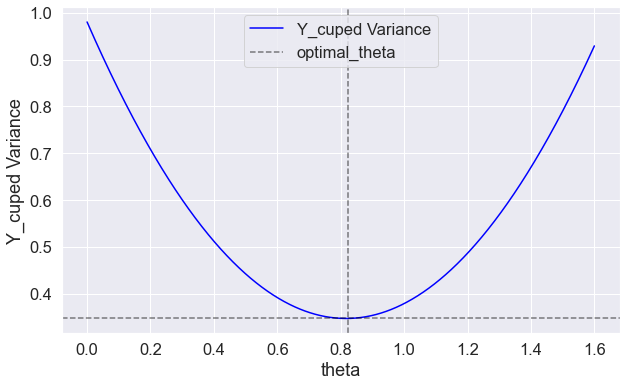

In [746]:
# численно проверим действительно рассчитываемая theta дает самую низкую дисперсию Y_cuped 
thetas = np.linspace(0, 1.6, 1000)
list_var = []

for theta_ in (thetas):
    y_cuped = df_control['post_value'] - theta_ * df_control['pre_value']
    list_var.append(y_cuped.var())

plt.figure(figsize = (10, 6))
sns.lineplot(x = thetas, y = list_var, label='Y_cuped Variance', color = 'blue')
plt.axvline(theta, label='optimal_theta', linestyle = '--', alpha=0.5, color = 'black')
plt.axhline(y = np.min(list_var), linestyle = '--', alpha=0.5, color = 'black')
plt.xlabel('theta')
plt.ylabel('Y_cuped Variance')
plt.legend()
plt.show()

Как видно из графика минимум дисперсии рассчитанный численно для Y-cuped очень близок к рассчитанной по формуле. Можем считать что мы проверили предположение о минимизации дисперсии при именно 

## Посмотрим распределение исходной и cuped метрики

В интеренете встречается несколько вариантов рассчета Y_cuped

$${Y}_{cuped} = {Y} - \theta {X}$$
$$Y_{cuped\,full} = {Y} - \theta {X} + \theta\mathbb{E}X\,$$

Давайте посмотрим, чем они различаются

Помним о том, что математической ожидание для pre данных должны быть равны для тестовой и для контрольной иначе методика не будет работать.

In [774]:
pre_mean = 1 
post_mean = 1

df = generate_corr_data(100, pre_mean, post_mean, corr=0.8)
theta = calculate_theta_basic(df['pre_value'], df['post_value'])

Y_cuped = df['post_value'] - theta * df['pre_value']
Y_cuped_full = df['post_value'] - theta * (df['pre_value'] - pre_mean)
Y_cuped_uncorrect = df['post_value'] - theta * df['pre_value'] + theta * np.mean(df['pre_value'])

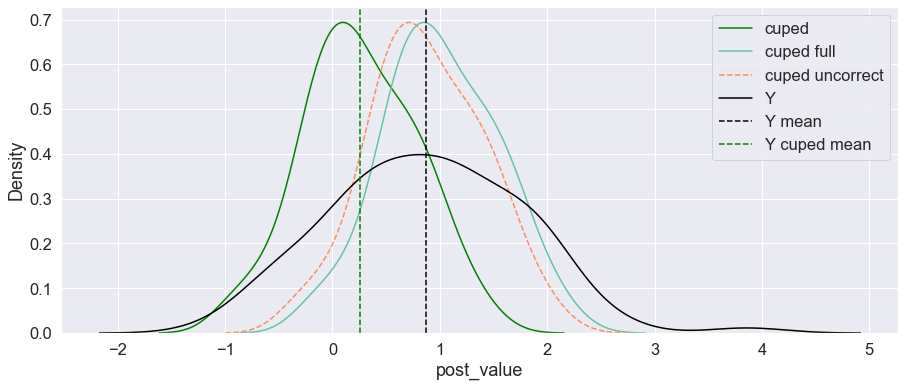

In [775]:
plt.figure(figsize = (15,6))
sns.kdeplot(Y_cuped, label = 'cuped', color = 'green')
sns.kdeplot(Y_cuped_full, label = 'cuped full')
sns.kdeplot(Y_cuped_uncorrect, label = 'cuped uncorrect', linestyle = '--')
sns.kdeplot(df['post_value'], label = 'Y', color = 'black')

plt.axvline(x = df['post_value'].mean(), color = 'black', label = 'Y mean', linestyle = '--')
plt.axvline(x = Y_cuped.mean(), color = 'green', linestyle = '--',label = 'Y cuped mean')
plt.legend()

- Мы видим, что рассчитанная Y cuped по сокращенному варианту явно не совпадает в математических ожиданиях с исходной метрикой.
- При этом Y cuped по полной формуле и Y cuped использующая выборочное среднее по pre данным совпадают в среднем значении с исходной метрикой.
- Дисперсия новых cuped метрик явно меньше, чем дисперсия
- Основная проблема с полной формулой в том, что мы не знаем истинное математическое ожидание pre данных. При этом использование выборочного среднего как замена математического ожидания несет угрозу  корректности Cuped ttest. Именно поэтому мы заранее назвали этот метод uncorrect и продемонстрируем его проблему при проверке критерии по мощности и стат значимости.
- забегая вперед можно сказать, что при соблюдении условия равенства математических ожиданий в test и control на препериоде, мы легко можем использовать сокращенный вариант расчета формулы. Т.к. в t-test мы рассматриваем уже не сами метрики а новую СВ - разницу средних между тестом и контролем. А поскольку мат ожидание и theta это просто константы равные для обеих групп. Они просто сокращаются.
- можно сказать, что короткая запись cuped метрики это уже подготовленная заранее метрика под t-критерий. Но если вы используете ее, то не стоит искать совпадения в средних с исходной метриках.
- далее в t-test мы будем использовать сокращенный вариант этой метрики.

# CUPED t-test

In [758]:
# сгенирируем данные для проведения теста на равенство средних и определим нужный размер выборки
from statsmodels.stats.power import tt_ind_solve_power

control_sd = 1
control_mean = 1
rel_effect = 0.1
treat_mean = control_mean*(1 + rel_effect)
mean_diff = treat_mean - control_mean
alpha = 0.05

# Расчет индекса Коэна 
cohen_d = mean_diff / control_sd

n = tt_ind_solve_power(effect_size = cohen_d, 
                       alpha = alpha, 
                       power = 0.8, 
                       ratio = 1, 
                       alternative = "two-sided")
n = round(n)
print('Минимальный размер выборки для достижения уровня значимости: {:.0f}'.format(round(n)))

Минимальный размер выборки для достижения уровня значимости: 1571


In [759]:
df_control = generate_corr_data(1000, 1, 1, corr=0.8)
df_test = generate_corr_data(1000, 1, 1.07, corr=0.8)

theta = calculate_theta_for_test(df_control['pre_value'], df_control['post_value'], df_pilot['pre_value'], df_pilot['post_value'])

Y_cuped_control = df_control['post_value'] - theta* df_control['pre_value']
Y_cuped_test = df_test['post_value'] - theta* df_test['pre_value']

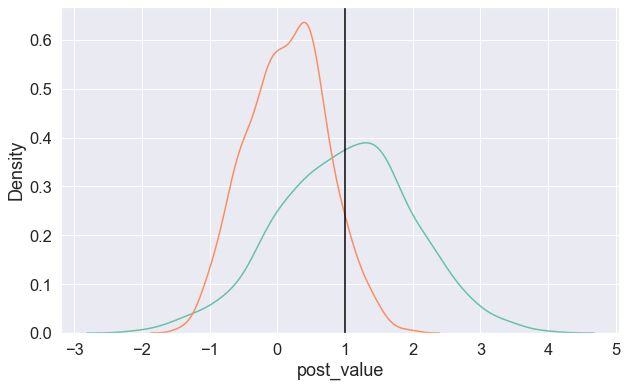

In [760]:
plt.figure(figsize = (10, 6))
sns.kdeplot(df_control['post_value'])
sns.kdeplot(Y_cuped_control)
plt.axvline(x= df_control['post_value'].mean(), color = 'black')

In [530]:
def get_basic_ttest(group_A, group_B):
    '''Проверяет гипотезу о равенстве средних для обычного среднего.
    return - t_stat, p_value'''
    
    t_stat, p_value = stats.ttest_ind(group_A, group_B)
    inference = {'t_stat': t_stat, 'p_value':p_value}
    return(inference)

def get_cuped_ttest(control_pre, control_post, test_pre, test_post):
    '''Проверяет гипотезу о равенстве средних CUPED вариант
    return - t_stat, p_value'''
    
    theta = calculate_theta_for_test(control_pre, control_post, test_pre, test_post)

    control_cuped = control_post - theta * control_pre
    test_cuped = test_post - theta * test_pre
    
    inference = get_basic_ttest(control_cuped, test_cuped)
    
    return(inference)

def get_cuped_ttest_full(control_pre, control_post, test_pre, test_post, pre_general_mean):
    '''Проверяет гипотезу о равенстве средних полный CUPED вариант с известным математическим ожиданием на пре периоде
    return - t_stat, p_value'''
    
    theta = calculate_theta_for_test(control_pre, control_post, test_pre, test_post)

    control_cuped = control_post - theta * (control_pre - pre_general_mean)
    test_cuped = test_post - theta * (test_pre - pre_general_mean)
    
    inference = get_basic_ttest(control_cuped, test_cuped)
    
    return(inference)

def get_cuped_ttest_full_bad(control_pre, control_post, test_pre, test_post):
    '''Проверяет гипотезу о равенстве средних CUPED вариант,
    где вместо генерального математического ожидания на pre периоде использую выборочное среднее
    return - t_stat, p_value'''
    
    theta = calculate_theta_for_test(control_pre, control_post, test_pre, test_post)

    control_cuped = control_post - theta * (control_pre - np.mean(control_pre))
    test_cuped = test_post - theta * (test_pre - np.mean(test_pre))
    
    inference = get_basic_ttest(control_cuped, test_cuped)
    
    return(inference)

In [783]:
# проведем разовый АБ-тест на сравнение средних
df_control = generate_corr_data(round(n), 1, 1, corr=0.8)
df_test = generate_corr_data(round(n), 1, 1.07, corr=0.8) # дадим эффект чуть ниже чем MDE? чтобы продемонстрировать рост мощности с CUPED
print('BASIC T-TEST:', get_basic_ttest(df_control['post_value'], df_test['post_value']))
print('CUPED T-TEST:', get_cuped_ttest(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value']))
print('CUPED T-TEST FULL:', get_cuped_ttest_full(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value'], 1))
print('CUPED T-TEST BAD:', get_cuped_ttest_full_bad(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value']))

BASIC T-TEST: {'t_stat': -1.5453392159765647, 'p_value': 0.1223650064658386}
CUPED T-TEST: {'t_stat': -3.857257367218804, 'p_value': 0.00011696900631223933}
CUPED T-TEST FULL: {'t_stat': -3.857257367218814, 'p_value': 0.00011696900631223445}
CUPED T-TEST BAD: {'t_stat': -2.5970674027714433, 'p_value': 0.009446226102130008}


Как видно по разовому тесту p-value и t-значение выглядит более "контростно". Что комвено говорит о большей мощности при принятии решения. Давайте оценим мощность и статзначимость такого доработанного критерия

## Оценка мощности и статзначимости

  0%|          | 0/10000 [00:00<?, ?it/s]

Мощность обычного t-test: 0.8012
Мощность CUPED t-test 0.9757
Мощность CUPED t-test full 0.9757
Мощность CUPED t-test full bad 0.9226
--------------
Стат значимость обычного t-test: 0.05
Стат значимость CUPED t-test 0.0468
Стат значимость CUPED t-test full 0.0468
Стат значимость CUPED t-test full bad 0.1557


Text(0.5, 1.0, 'p-value ecdf for AA-tests')

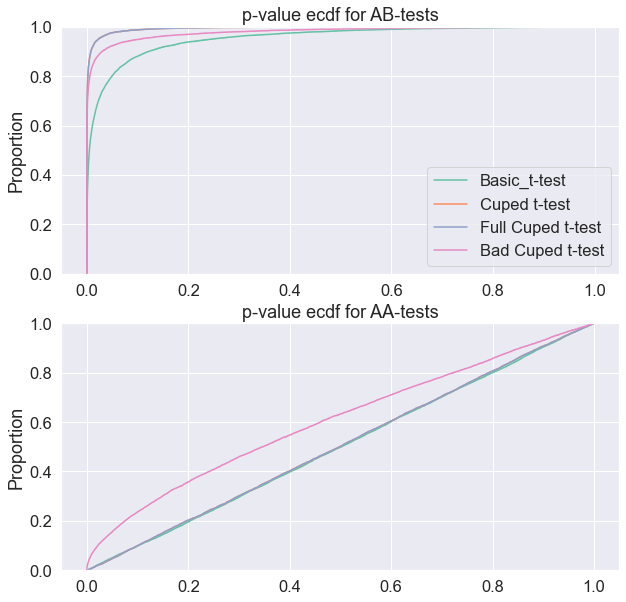

In [532]:
# рассчитаем базовый размер выборки для обычного теста.
# будет рассчитывать
control_sd = 1 # в функции generate_corr_data генерируются нормальные величины с std = 1
control_mean = 1
rel_effect = 0.1
treat_mean = control_mean*(1 + rel_effect)
mean_diff = treat_mean - control_mean
alpha = 0.05

# Расчет индекса Коэна 
cohen_d = mean_diff / control_sd

n = tt_ind_solve_power(effect_size = cohen_d, 
                       alpha = alpha, 
                       power = 0.8, 
                       ratio = 1, 
                       alternative = "two-sided")
sample_size = round(n)

# симуляция теста
corr = 0.7

basic_ttest_pval_list_AB = []
cuped_ttest_pval_list_AB = []
cuped_ttest_pval_list_AB_full = []
cuped_ttest_pval_list_AB_full_bad = []

basic_ttest_pval_list_AA = []
cuped_ttest_pval_list_AA = []
cuped_ttest_pval_list_AA_full = []
cuped_ttest_pval_list_AA_full_bad = []


sim_num = 10000

for _ in tqdm( range(sim_num)):
    #генерируем данные
    df_control_1 = generate_corr_data(sample_size, control_mean, control_mean, corr = corr) # создадим контрольную группу 1
    df_control_2 = generate_corr_data(sample_size, control_mean, control_mean, corr = corr) # создадим контрольную группу 2 (для АА-теста)
    df_test = generate_corr_data(sample_size, control_mean, treat_mean, corr = corr) # создадим тестовую группу с эффектом
    
    #проводим тесты АБ вариант. для анализа мощности
    basic_ttest_pval_AB = get_basic_ttest(df_control_1['post_value'], df_test['post_value'])['p_value']
    cuped_ttest_pval_AB = get_cuped_ttest(df_control_1['pre_value'], df_control_1['post_value'], df_test['pre_value'], df_test['post_value'])['p_value']
    cuped_ttest_pval_AB_full = get_cuped_ttest_full(df_control_1['pre_value'], df_control_1['post_value'], df_test['pre_value'], df_test['post_value'], control_mean)['p_value']
    cuped_ttest_pval_AB_full_bad = get_cuped_ttest_full_bad(df_control_1['pre_value'], df_control_1['post_value'], df_test['pre_value'], df_test['post_value'])['p_value']
    
    #проводим тесты АА вариант. для анализа стат. значиости
    basic_ttest_pval_AA = get_basic_ttest(df_control_1['post_value'], df_control_2['post_value'])['p_value']
    cuped_ttest_pval_AA = get_cuped_ttest(df_control_1['pre_value'], df_control_1['post_value'], df_control_2['pre_value'], df_control_2['post_value'])['p_value']
    cuped_ttest_pval_AA_full = get_cuped_ttest_full(df_control_1['pre_value'], df_control_1['post_value'], df_control_2['pre_value'], df_control_2['post_value'], control_mean)['p_value']
    cuped_ttest_pval_AA_full_bad = get_cuped_ttest_full_bad(df_control_1['pre_value'], df_control_1['post_value'], df_control_2['pre_value'], df_control_2['post_value'])['p_value']

    #собираем все в массивы
    basic_ttest_pval_list_AB.append(basic_ttest_pval_AB)
    cuped_ttest_pval_list_AB.append(cuped_ttest_pval_AB)
    cuped_ttest_pval_list_AB_full.append(cuped_ttest_pval_AB_full)
    cuped_ttest_pval_list_AB_full_bad.append(cuped_ttest_pval_AB_full_bad)
    
    basic_ttest_pval_list_AA.append(basic_ttest_pval_AA)
    cuped_ttest_pval_list_AA.append(cuped_ttest_pval_AA)
    cuped_ttest_pval_list_AA_full.append(cuped_ttest_pval_AA_full)
    cuped_ttest_pval_list_AA_full_bad.append(cuped_ttest_pval_AA_full_bad)

#оценка мощности    
basic_ttest_power = (np.array(basic_ttest_pval_list_AB) < 0.05).sum() / sim_num
cuped_ttest_power = (np.array(cuped_ttest_pval_list_AB) < 0.05).sum() / sim_num
cuped_ttest_power_full = (np.array(cuped_ttest_pval_list_AB_full) < 0.05).sum() / sim_num
cuped_ttest_power_full_bad = (np.array(cuped_ttest_pval_list_AB_full_bad) < 0.05).sum() / sim_num


#оценка стат.значимости  
basic_tt_alpha = (np.array(basic_ttest_pval_list_AA) < 0.05).sum() / sim_num
cuped_ttest_alpha = (np.array(cuped_ttest_pval_list_AA) < 0.05).sum() / sim_num
cuped_ttest_alpha_full = (np.array(cuped_ttest_pval_list_AA_full) < 0.05).sum() / sim_num
cuped_ttest_alpha_full_bad = (np.array(cuped_ttest_pval_list_AA_full_bad) < 0.05).sum() / sim_num


print('Мощность обычного t-test:', basic_ttest_power)
print('Мощность CUPED t-test', cuped_ttest_power)
print('Мощность CUPED t-test full', cuped_ttest_power_full)
print('Мощность CUPED t-test full bad', cuped_ttest_power_full_bad)

print('--------------')
print('Стат значимость обычного t-test:', basic_tt_alpha)
print('Стат значимость CUPED t-test', cuped_ttest_alpha)
print('Стат значимость CUPED t-test full', cuped_ttest_alpha_full)
print('Стат значимость CUPED t-test full bad', cuped_ttest_alpha_full_bad)

# PLOT
fig, axes = plt.subplots(2, figsize=(10,10))
sns.ecdfplot(ax=axes[0], data = basic_ttest_pval_list_AB, label = 'Basic_t-test')
sns.ecdfplot(ax=axes[0], data = np.array(cuped_ttest_pval_list_AB), label = 'Cuped t-test')
sns.ecdfplot(ax=axes[0], data = np.array(cuped_ttest_pval_list_AB_full), label = 'Full Cuped t-test')
sns.ecdfplot(ax=axes[0], data = np.array(cuped_ttest_pval_list_AB_full_bad), label = 'Bad Cuped t-test')
axes[0].set_title('p-value ecdf for AB-tests')
axes[0].legend(loc='lower right')

sns.ecdfplot(ax=axes[1], data = basic_ttest_pval_list_AA)
sns.ecdfplot(ax=axes[1], data = np.array(cuped_ttest_pval_list_AA))
sns.ecdfplot(ax=axes[1], data = np.array(cuped_ttest_pval_list_AA_full))
sns.ecdfplot(ax=axes[1], data = np.array(cuped_ttest_pval_list_AA_full_bad))
axes[1].set_title('p-value ecdf for AA-tests')

- Через симмуляции мы подтвердили возросший уровень мощности CUPED теста при корреляции 0.7. Он составил почти 0.97
- Также мы увидели основную проблему неправильного метода рассчета CUPED метрики. Страдает уровень ошибки альфа
- Это можно было бы исправить, если вы каким-то чудом зналибы истинное математическое ожидание на pre периоде. но в реальности мы его никогда не знаем. Поэтому будем использовать сокращенную метрику CUPED. Она дает такое же сокращение дисперсии что и full вариант. И дает несмещенную оценку эффекта.

# Проверка несмещенности эффекта

  0%|          | 0/5000 [00:00<?, ?it/s]

General means uplift = 0.10000000000000009
Basic mean(means diff) = 0.1003597719442453
Cuped mean(means diff) = 0.10054615348323151
---------------------
BAsic means_diff std = 0.03541146061135526
Cuped means_diff std = 0.021441065373462846


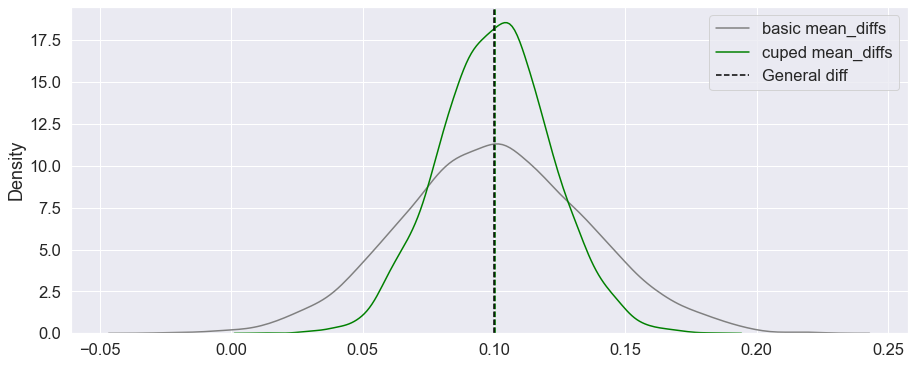

In [601]:
corr = 0.8
sim_num = 5000
basic_mean_diffs_list = []
cuped_mean_diffs_list = []
for _ in tqdm(range(sim_num)):
    #генерируем данные
    df_control = generate_corr_data(sample_size, control_mean, control_mean, corr = corr) # создадим контрольную группу 1
    df_test = generate_corr_data(sample_size, control_mean, treat_mean, corr = corr) # создадим тестовую группу с эффектом
    basic_mean_diff = df_test['post_value'].mean() - df_control['post_value'].mean()
    
    #проводим тесты АБ вариант. для анализа мощности
    theta = calculate_theta_for_test(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value'] )

    control_cuped = df_control['post_value'] - theta * df_control['pre_value']
    test_cuped = df_test['post_value'] - theta * df_test['pre_value']
    cuped_mean_diff = test_cuped.mean() - control_cuped.mean()
    
    basic_mean_diffs_list.append(basic_mean_diff)
    cuped_mean_diffs_list.append(cuped_mean_diff)

print('General means uplift =', treat_mean - control_mean)
print('Basic mean(means diff) =', np.mean(basic_mean_diffs_list))
print('Cuped mean(means diff) =', np.mean(cuped_mean_diffs_list))
print('---------------------') 
print('BAsic means_diff std =',  np.std(basic_mean_diffs_list))
print('Cuped means_diff std =', np.std(cuped_mean_diffs_list))    
    
plt.figure(figsize = (15, 6))
sns.kdeplot(basic_mean_diffs_list, label = 'basic mean_diffs', color = 'grey')
sns.kdeplot(cuped_mean_diffs_list, label = 'cuped mean_diffs', color = 'green')
plt.axvline(x = np.mean(basic_mean_diffs_list), linestyle = '--', color = 'grey')
plt.axvline(x = np.mean(cuped_mean_diffs_list),  linestyle = '--', color = 'green')
plt.axvline(x = treat_mean - control_mean, color = 'black', linestyle = '--', label = 'General diff')
plt.legend()

In [ ]:
Мы видим что CUPED метрика точно оценивает величину абсолютного эффекта таже как и базовая разница в средних
Но мера разброса тако

## Давайте проверим, как ведет себя прирост роста мощности теста при разном уровне корреляции между параметрами

In [304]:
corr_linespace = np.arange(0, 1, 0.01) #создадим линейное пространство корреляций для 
sim_num = 1000
cuped_ttest_power_list = []
for corr in tqdm(corr_linespace): # для каждой корреляции оценим мощность на кол-ве наблюдений достаточных для базового критерия
    
    cuped_ttest_pval_list = []
    for _ in range(sim_num):
        df_control_1 = generate_corr_data(sample_size, control_mean, control_mean, corr = corr) # создадим контрольную группу 1
        df_test = generate_corr_data(sample_size, control_mean, treat_mean, corr = corr) # создадим тестовую группу с эффектом

        cuped_ttest_pval = get_cuped_ttest(df_control_1['pre_value'], df_control_1['post_value'], df_test['pre_value'], df_test['post_value'])['p_value']
        cuped_ttest_pval_list.append(cuped_ttest_pval)

    cuped_ttest_power = (np.array(cuped_ttest_pval_list) < 0.05).sum() / sim_num
    cuped_ttest_power_list.append(cuped_ttest_power)

  0%|          | 0/100 [00:00<?, ?it/s]

In [301]:
# рассчитаем границы ДИ для мощности
lower_ci_list = []
upper_ci_list = []
for i in cuped_ttest_power_list:
    lower_ci = proportion_confint(i * sim_num, sim_num)[0]
    upper_ci = proportion_confint(i * sim_num, sim_num)[1]
    lower_ci_list.append(lower_ci)
    upper_ci_list.append(upper_ci)

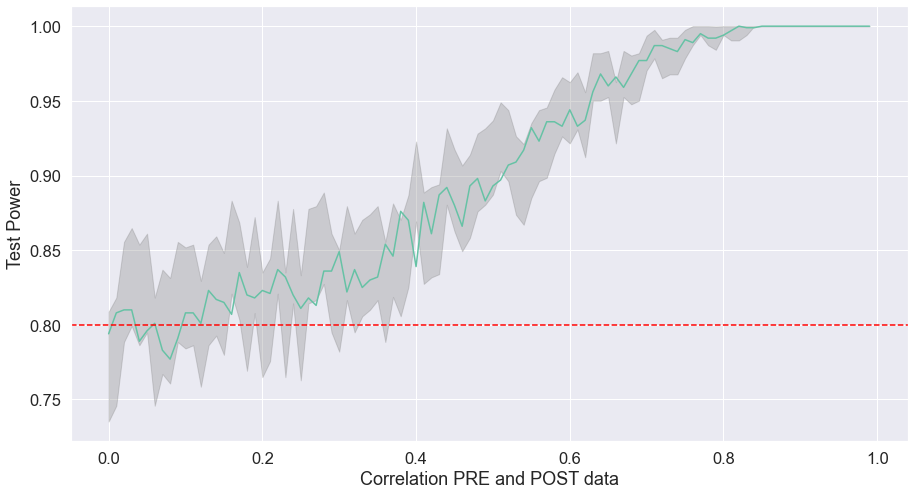

In [508]:
# отрисуем график
plt.figure(figsize = (15,8))
sns.lineplot(x = corr_linespace, y = cuped_ttest_power_list)
plt.xlabel('Correlation PRE and POST data')
plt.ylabel('Test Power')
plt.axhline(y = 0.8, linestyle = '--', color = 'red')
plt.fill_between(corr_linespace, lower_ci_list, upper_ci_list, color = 'grey', alpha=0.3)

- Видно, что по мере роста корреляции между pre и post данными мощность теста возрастает.
- Так при корреляции 0.5 мощность составляет около 0.9. При корреляции 0.8 мощность таких данных на данном размере выборке составляет около 1.0.
- Мы начинали симуляцию с размера выборки достаточного для проведения базового t-test.
- Мы видим, что при нулевой корреляции CUPED просто выдает такую же мощность что и базовый t-test. Т.е. ухудшить мощность относительно базового теста он не сможет. Это хорошие новости.

## Работа с пропущенными значениями

Частой проблемой из-за чего CUPED теряет в своей эффективности является отсутствие до экспериментальных данных у части пользователей.
Когда отсутствие преэсперементальных данных наблюдается у большинства пользователей, то CUPED может полностью перестать работать.
Хорошая новость в том, что хуже чем базовый тест он все равно не станет.
Как можно работать с пропущенными значениями:
- заменить нулями
- заменить средним или медианным значением
- использовать ML для предсказания pre-поведения

In [626]:
empty_value_proportion = 0.5
# проведем разовый АБ-тест на сравнение средних с отсутствующими данным
np.random.seed(5)
df_control = generate_corr_data(sample_size, 1, 1, corr=0.8)
df_test = generate_corr_data(sample_size, 1, 1.07, corr=0.8) # дадим эффект чуть ниже чем MDE

df_control['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_control)) == 1] = None #создадим и заполним пустые значения нулями
df_control['pre_value'].fillna(0, inplace = True)

df_test['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_test)) == 1] = None
df_test['pre_value'].fillna(0, inplace = True)

print('BASIC T-TEST:', get_basic_ttest(df_control['post_value'], df_test['post_value']))
print('CUPED T-TEST:', get_cuped_ttest(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value']))

BASIC T-TEST: {'t_stat': -2.1635292323231914, 'p_value': 0.030575698464649012}
CUPED T-TEST: {'t_stat': -3.2586658159345925, 'p_value': 0.00113130468160154}


как видно из разового теста p-value cuped теста все еще ниже. Что косвено иллюстрируем что возможно мощность все еще будет выше. Давайте это проверим при оценке мощности

  0%|          | 0/1000 [00:00<?, ?it/s]

Корреляция PRE и POST данных при замене нулями: 0.4609988884292219
Корреляция PRE и POST данных при замене средними: 0.5658153172961528
--------------
Мощность обычного t-test: 0.5
Мощность CUPED t-test с заменой пропущенных данных на нули 0.617
Мощность CUPED t-test с заменой пропущенных данных на среднее значение 0.686
--------------
Стат значимость обычного t-test: 0.055
Стат значимость CUPED с заменой пропущенных данных на нули 0.042
Стат значимость CUPED с заменой пропущенных данных на среднее значение 0.045


Text(0.5, 1.0, 'p-value ecdf for AA-tests')

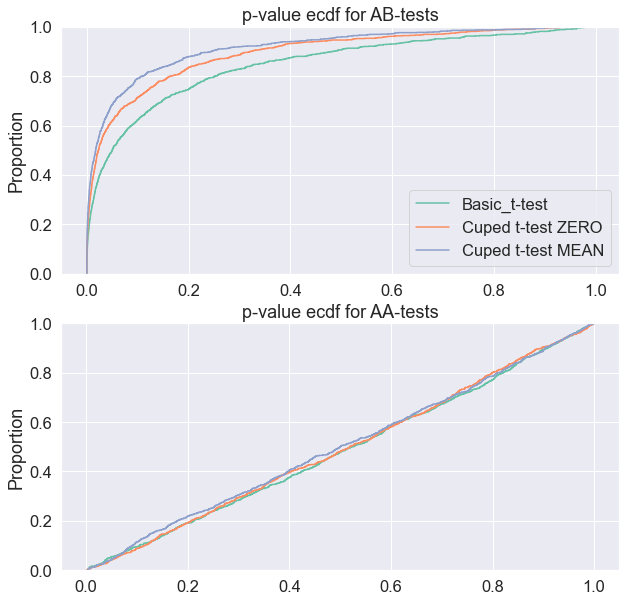

In [648]:
empty_value_proportion = 0.5
sim_num = 1000

basic_pval_list_AA = []
cuped_pval_list_zero_AA = []
cuped_pval_list_mean_AA = []

basic_pval_list_AB = []
cuped_pval_list_zero_AB = []
cuped_pval_list_mean_AB = []

zero_corr_list = []
mean_corr_list = []

for _ in tqdm(range(sim_num)):
    # AB simulation ---------------------------------------
    df_control = generate_corr_data(sample_size, 1, 1, corr=0.8)
    df_test = generate_corr_data(sample_size, 1, 1.07, corr=0.8) # дадим эффект чуть ниже чем MDE

    df_control_zero = df_control.copy()
    df_control_mean = df_control.copy()

    df_test_zero = df_test.copy()
    df_test_mean = df_test.copy()

    # замена значений нулями
    df_control_zero['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_control_zero)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_zero['pre_value'].fillna(0, inplace = True)

    df_test_zero['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_test_zero)) == 1] = None
    df_test_zero['pre_value'].fillna(0, inplace = True)

    # замена значений средним значением
    pre_mean = df_test['pre_value'].append(df_control['pre_value']).mean()
    df_control_mean['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_control_mean)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_mean['pre_value'].fillna(pre_mean, inplace = True)

    df_test_mean['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_test_mean)) == 1] = None
    df_test_mean['pre_value'].fillna(pre_mean, inplace = True)
    
    #рассчет корреляций
    zero_corr = np.corrcoef(df_control_zero['pre_value'].append(df_test_zero['pre_value']), df_control_zero['post_value'].append(df_test_zero['post_value']))[0,1]
    mean_corr = np.corrcoef(df_control_mean['pre_value'].append(df_test_mean['pre_value']), df_control_mean['post_value'].append(df_test_mean['post_value']))[0,1]
    zero_corr_list.append(zero_corr)
    mean_corr_list.append(mean_corr)
    
    # рассчет тестов
    basic_pval = get_basic_ttest(df_control['post_value'], df_test['post_value'])['p_value']
    cuped_pval_zero = get_cuped_ttest(df_control_zero['pre_value'], df_control_zero['post_value'], df_test_zero['pre_value'], df_test_zero['post_value'])['p_value']
    cuped_pval_mean = get_cuped_ttest(df_control_mean['pre_value'], df_control_mean['post_value'], df_test_mean['pre_value'], df_test_mean['post_value'])['p_value']
    
    basic_pval_list_AB.append(basic_pval)
    cuped_pval_list_zero_AB.append(cuped_pval_zero)
    cuped_pval_list_mean_AB.append(cuped_pval_mean)
    
    # AA simulation ---------------------------------------
    df_control = generate_corr_data(sample_size, 1, 1, corr=0.8)
    df_test = generate_corr_data(sample_size, 1, 1, corr=0.8) # нет эффекта

    df_control_zero = df_control.copy()
    df_control_mean = df_control.copy()

    df_test_zero = df_test.copy()
    df_test_mean = df_test.copy()

    # замена значений нулями
    df_control_zero['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_control_zero)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_zero['pre_value'].fillna(0, inplace = True)

    df_test_zero['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_test_zero)) == 1] = None
    df_test_zero['pre_value'].fillna(0, inplace = True)

    # замена значений средним значением
    pre_mean = df_test['pre_value'].append(df_control['pre_value']).mean()
    df_control_mean['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_control_mean)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_mean['pre_value'].fillna(pre_mean, inplace = True)

    df_test_mean['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_test_mean)) == 1] = None
    df_test_mean['pre_value'].fillna(pre_mean, inplace = True)
    
    # рассчет тестов
    basic_pval = get_basic_ttest(df_control['post_value'], df_test['post_value'])['p_value']
    cuped_pval_zero = get_cuped_ttest(df_control_zero['pre_value'], df_control_zero['post_value'], df_test_zero['pre_value'], df_test_zero['post_value'])['p_value']
    cuped_pval_mean = get_cuped_ttest(df_control_mean['pre_value'], df_control_mean['post_value'], df_test_mean['pre_value'], df_test_mean['post_value'])['p_value']
    
    basic_pval_list_AA.append(basic_pval)
    cuped_pval_list_zero_AA.append(cuped_pval_zero)
    cuped_pval_list_mean_AA.append(cuped_pval_mean)   
    
    
power_basic = np.sum(np.array(basic_pval_list_AB) < 0.05) / sim_num
power_cuped_zero = np.sum(np.array(cuped_pval_list_zero_AB) < 0.05) / sim_num
power_cuped_mean = np.sum(np.array(cuped_pval_list_mean_AB) < 0.05) / sim_num

alpha_basic = np.sum(np.array(basic_pval_list_AA) < 0.05) / sim_num
alpha_cuped_zero = np.sum(np.array(cuped_pval_list_zero_AA) < 0.05) / sim_num
alpha_cuped_mean = np.sum(np.array(cuped_pval_list_mean_AA) < 0.05) / sim_num

print('Корреляция PRE и POST данных при замене нулями:', np.mean(zero_corr_list))
print('Корреляция PRE и POST данных при замене средними:', np.mean(mean_corr_list))
print('--------------')
print('Мощность обычного t-test:', power_basic)
print('Мощность CUPED t-test с заменой пропущенных данных на нули', power_cuped_zero)
print('Мощность CUPED t-test с заменой пропущенных данных на среднее значение', power_cuped_mean)
print('--------------')
print('Стат значимость обычного t-test:', alpha_basic)
print('Стат значимость CUPED с заменой пропущенных данных на нули', alpha_cuped_zero)
print('Стат значимость CUPED с заменой пропущенных данных на среднее значение', alpha_cuped_mean)

# PLOT
fig, axes = plt.subplots(2, figsize=(10,10))
sns.ecdfplot(ax=axes[0], data = basic_pval_list_AB, label = 'Basic_t-test')
sns.ecdfplot(ax=axes[0], data = np.array(cuped_pval_list_zero_AB), label = 'Cuped t-test ZERO')
sns.ecdfplot(ax=axes[0], data = np.array(cuped_pval_list_mean_AB), label = 'Cuped t-test MEAN')
axes[0].set_title('p-value ecdf for AB-tests')
axes[0].legend(loc='lower right')

sns.ecdfplot(ax=axes[1], data = basic_pval_list_AA)
sns.ecdfplot(ax=axes[1], data = np.array(cuped_pval_list_zero_AA))
sns.ecdfplot(ax=axes[1], data = np.array(cuped_pval_list_mean_AA))
axes[1].set_title('p-value ecdf for AA-tests')

In [654]:
axes

array([<AxesSubplot:title={'center':'p-value ecdf for AB-tests'}, ylabel='Proportion'>,
       <AxesSubplot:title={'center':'p-value ecdf for AA-tests'}, ylabel='Proportion'>],
      dtype=object)

Text(0.5, 1.0, 'Pre Post Valus with MEAN replacement')

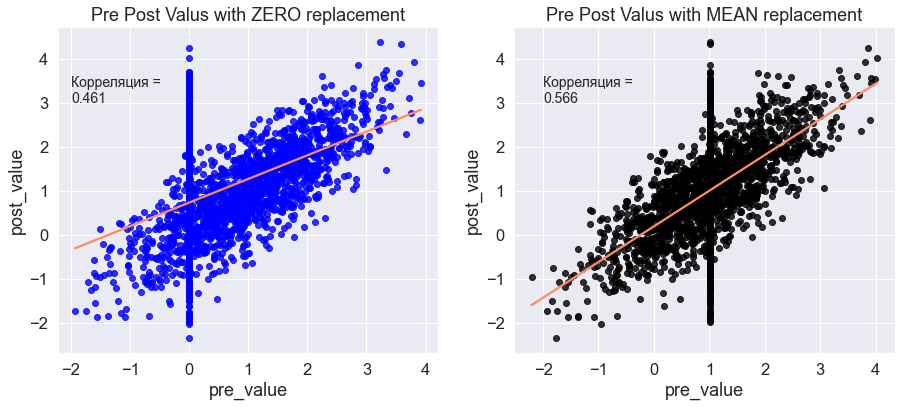

In [698]:
fig, axes = plt.subplots(1, 2 , figsize=(15,6))
#sns.scatterplot(ax=axes[0], x = df_control_zero['pre_value'].append(df_test_zero['pre_value']), y = df_control_zero['post_value'].append(df_test_zero['post_value']))
#sns.scatterplot(ax=axes[1], x = df_control_mean['pre_value'].append(df_test_mean['pre_value']), y = df_control_mean['post_value'].append(df_test_mean['post_value']))
sns.regplot(ax=axes[0], x = df_control_zero['pre_value'].append(df_test_zero['pre_value']), y = df_control_zero['post_value'].append(df_test_zero['post_value']), color = 'blue', ci=None, line_kws ={"color": "C1"})
sns.regplot(ax=axes[1], x = df_control_mean['pre_value'].append(df_test_mean['pre_value']), y = df_control_mean['post_value'].append(df_test_mean['post_value']), color = 'black',ci=None, line_kws ={"color": "C1"})
axes[0].text(x = -2, y = 3, s = 'Корреляция = \n{:.3f}'.format(np.mean(zero_corr_list)), size = 14)
axes[1].text(x = -2, y = 3, s = 'Корреляция = \n{:.3f}'.format(np.mean(mean_corr_list)), size = 14)
axes[0].set_title('Pre Post Valus with ZERO replacement')
axes[1].set_title('Pre Post Valus with MEAN replacement')

Как видно из графика выше замена пустых значений на среднюю дает лучшие результаты чем замена на нули
Происходит это из-за того что при среднем значении не меняется 

Давайте посмотрим где находится оптимальное значение для замены пустых значений. Как обычно попробуем это найти с помощью симуляций

In [722]:
sim_num = 100
empty_value_proportion = 0.5
replacement_values = np.arange(-1, 4, 0.05)

corr_list_full = []
power_list_full = []
# Для каждого возможного значения для замены пустых значений найдем среднюю корреляцию и мощность теста

for replacement_value in tqdm(replacement_values): 
    corr_list = []
    cuped_pval_list = []
    for _ in range(sim_num): # проводим симмуляию для конкретного значения replacement_value
        # генерируем данные
        df_control = generate_corr_data(sample_size, 1, 1, corr=0.8)
        df_test = generate_corr_data(sample_size, 1, 1.07, corr=0.8)
        
        # создаем пустые значения
        df_control['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_control_mean)) == 1] = None #создадим и заполним пустые значения нулями
        df_control['pre_value'].fillna(replacement_value, inplace = True)
        
        # заполняем пустые значения replacement_value
        df_test['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_test_mean)) == 1] = None
        df_test['pre_value'].fillna(replacement_value, inplace = True)

        # рассчет тестов
        cuped_pval = get_cuped_ttest(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value'])['p_value']
        cuped_pval_list.append(cuped_pval)

        # рассчет корреляции
        corr = np.corrcoef(df_control['pre_value'].append(df_test['pre_value']), df_control['post_value'].append(df_test['post_value']))[0,1]
        corr_list.append(corr)
    # аггрегация нужных значения по всем симуляциям
    power = np.sum(np.array(cuped_pval_list) < 0.05) / sim_num
    avg_corr = np.mean(corr_list)
    power_list_full.append(power)
    corr_list_full.append(avg_corr)

  0%|          | 0/100 [00:00<?, ?it/s]

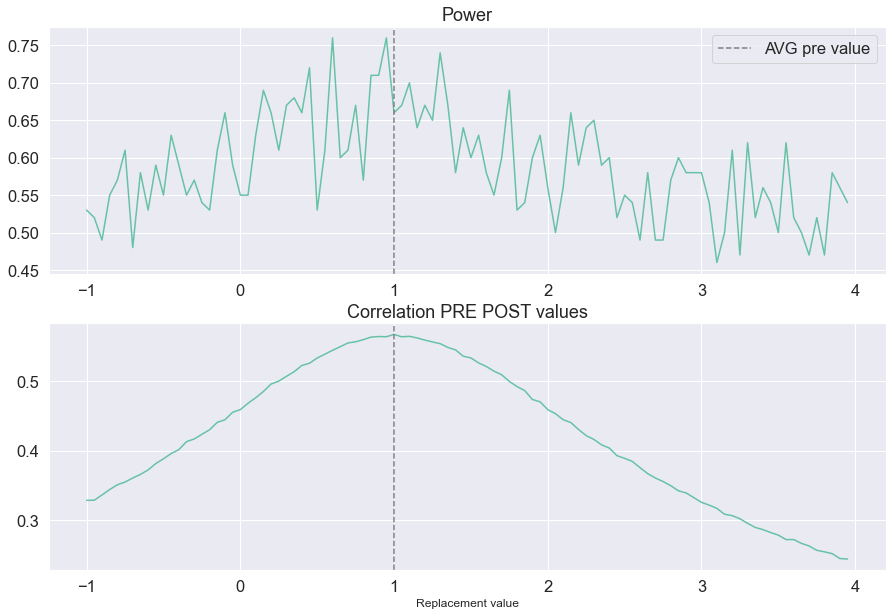

In [728]:
fig, axes = plt.subplots(2, figsize=(15,10))
sns.lineplot(ax=axes[0], y = power_list_full, x = replacement_values)
axes[0].set_title('Power')
sns.lineplot(ax=axes[1], y = corr_list_full, x = replacement_values)
axes[1].set_title('Correlation PRE POST values')
plt.xlabel(xlabel = 'Replacement value', fontsize = 12)
axes[0].axvline(x = 1, linestyle = '--', label = 'AVG pre value', color = 'gray')
axes[1].axvline(x = 1, linestyle = '--', color = 'gray')
axes[0].legend()

Как видно из графиков выше оптимум по замене пустых значений находится в значении среднего значения на объединенных PRE данных
Именно при таком положении корреляция PRE POST данных и мощность послеующего теста максимальны

Давайте посмотрим как ведет себя тест при разном уровне пропущенных данных

In [625]:
empty_value_proportion = 0.5
# проведем разовый АБ-тест на сравнение средних с отсутствующими данным
np.random.seed(5)
df_control = generate_corr_data(sample_size, 1, 1, corr=0.8)
df_test = generate_corr_data(sample_size, 1, 1.07, corr=0.8) # дадим эффект чуть ниже чем MDE

df_control['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_control)) == 1] = None #создадим и заполним пустые значения нулями
df_control['pre_value'].fillna(df_control['pre_value'].mean(), inplace = True)

df_test['pre_value'][np.random.binomial(1, empty_value_proportion, len(df_test)) == 1] = None
df_test['pre_value'].fillna(df_test['pre_value'].mean(), inplace = True)

print('BASIC T-TEST:', get_basic_ttest(df_control['post_value'], df_test['post_value']))
print('CUPED T-TEST:', get_cuped_ttest(df_control['pre_value'], df_control['post_value'], df_test['pre_value'], df_test['post_value']))

BASIC T-TEST: {'t_stat': -2.1635292323231914, 'p_value': 0.030575698464649012}
CUPED T-TEST: {'t_stat': -3.9524924261764736, 'p_value': 7.904563207604134e-05}


При пропуске в 50% данных, CUPED все еще работает.
Давайте посмотрим как будет вести себя с большим объемом пропусков.

  0%|          | 0/500 [00:00<?, ?it/s]

Мощность CUPED t-test без пропуска в данных 0.768
Мощность CUPED t-test без 10% пропуском в данных 0.716
Мощность CUPED t-test без 30% пропуском в данных 0.624
Мощность CUPED t-test без 50% пропуском в данных 0.604
Мощность CUPED t-test без 80% пропуском в данных 0.532
Мощность обычного t-test: 0.482


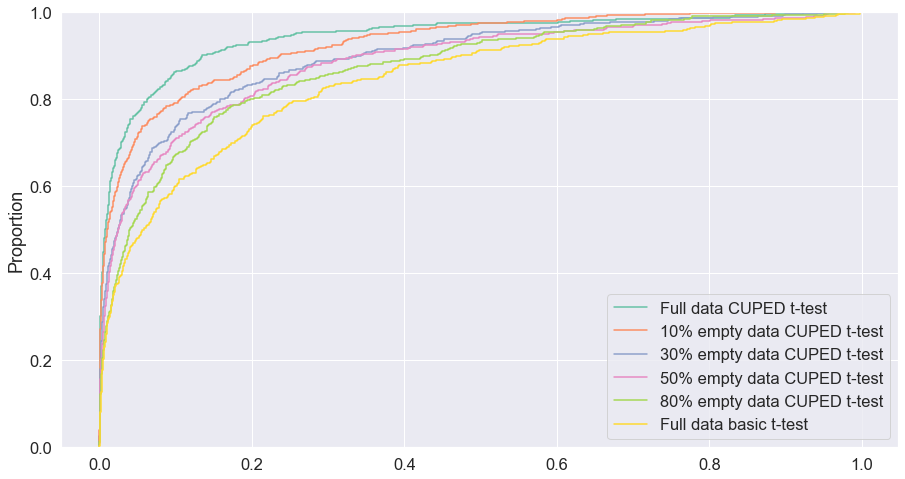

In [730]:
# симуляция теста
corr = 0.7
sample_size = 1571

basic_ttest_pval_list = []
basic_cuped_ttest_pval_list = []
empty10_cuped_ttest_pval_list = []
empty30_cuped_ttest_pval_list = []
empty50_cuped_ttest_pval_list = []
empty80_cuped_ttest_pval_list = []

sim_num = 500


for _ in tqdm(range(sim_num)):
    
    # full basic data CUPED
    df_control_full = generate_corr_data(sample_size, 1, 1, corr=corr)
    df_test_full = generate_corr_data(sample_size, 1, 1.07, corr=corr) # дадим эффект чуть ниже чем MDE
    
    basic_ttest_pval = get_basic_ttest(df_control_full['post_value'], df_test_full['post_value'])['p_value']
    basic_cuped_ttest_pval = get_cuped_ttest(df_control_full['pre_value'], df_control_full['post_value'], df_test_full['pre_value'], df_test_full['post_value'])['p_value']
    basic_ttest_pval_list.append(basic_ttest_pval)
    basic_cuped_ttest_pval_list.append(basic_cuped_ttest_pval)
    
    
    # empty 10% of pre data
    df_control_empty10 = generate_corr_data(sample_size, 1, 1, corr=corr)
    df_test_empty10 = generate_corr_data(sample_size, 1, 1.07, corr=corr) # дадим эффект чуть ниже чем MDE
    df_control_empty10['pre_value'][np.random.binomial(1, 0.1, len(df_control_empty10)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_empty10['pre_value'].fillna(0, inplace = True)
    df_test_empty10['pre_value'][np.random.binomial(1, 0.1, len(df_test_empty10)) == 1] = None
    df_test_empty10['pre_value'].fillna(0, inplace = True)
    
    empty10_cuped_ttest_pval = get_cuped_ttest(df_control_empty10['pre_value'], df_control_empty10['post_value'], df_test_empty10['pre_value'], df_test_empty10['post_value'])['p_value']
    empty10_cuped_ttest_pval_list.append(empty10_cuped_ttest_pval)
    
    # empty 30% of pre data
    df_control_empty30 = generate_corr_data(sample_size, 1, 1, corr=corr)
    df_test_empty30 = generate_corr_data(sample_size, 1, 1.07, corr=corr) # дадим эффект чуть ниже чем MDE
    df_control_empty30['pre_value'][np.random.binomial(1, 0.3, len(df_control_empty30)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_empty30['pre_value'].fillna(0, inplace = True)
    df_test_empty30['pre_value'][np.random.binomial(1, 0.3, len(df_test_empty30)) == 1] = None
    df_test_empty30['pre_value'].fillna(0, inplace = True)
    
    empty30_cuped_ttest_pval = get_cuped_ttest(df_control_empty30['pre_value'], df_control_empty30['post_value'], df_test_empty30['pre_value'], df_test_empty30['post_value'])['p_value']
    empty30_cuped_ttest_pval_list.append(empty30_cuped_ttest_pval)
    
    # empty 50% of pre data
    df_control_empty50 = generate_corr_data(sample_size, 1, 1, corr=corr)
    df_test_empty50 = generate_corr_data(sample_size, 1, 1.07, corr=corr) # дадим эффект чуть ниже чем MDE
    df_control_empty50['pre_value'][np.random.binomial(1, 0.5, len(df_control_empty50)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_empty50['pre_value'].fillna(0, inplace = True)
    df_test_empty50['pre_value'][np.random.binomial(1, 0.5, len(df_test_empty50)) == 1] = None
    df_test_empty50['pre_value'].fillna(0, inplace = True)
    
    empty50_cuped_ttest_pval = get_cuped_ttest(df_control_empty50['pre_value'], df_control_empty50['post_value'], df_test_empty50['pre_value'], df_test_empty50['post_value'])['p_value']
    empty50_cuped_ttest_pval_list.append(empty50_cuped_ttest_pval)
    
    # empty 80% of pre data
    df_control_empty80 = generate_corr_data(sample_size, 1, 1, corr=corr)
    df_test_empty80 = generate_corr_data(sample_size, 1, 1.07, corr=corr) # дадим эффект чуть ниже чем MDE
    df_control_empty80['pre_value'][np.random.binomial(1, 0.8, len(df_control_empty80)) == 1] = None #создадим и заполним пустые значения нулями
    df_control_empty80['pre_value'].fillna(0, inplace = True)
    df_test_empty80['pre_value'][np.random.binomial(1, 0.8, len(df_test_empty80)) == 1] = None
    df_test_empty80['pre_value'].fillna(0, inplace = True)
    
    empty80_cuped_ttest_pval = get_cuped_ttest(df_control_empty80['pre_value'], df_control_empty80['post_value'], df_test_empty80['pre_value'], df_test_empty80['post_value'])['p_value']
    empty80_cuped_ttest_pval_list.append(empty80_cuped_ttest_pval)
    
basic_ttest_power = (np.array(basic_ttest_pval_list) < 0.05).sum() / sim_num
basic_cuped_ttest_power = (np.array(basic_cuped_ttest_pval_list) < 0.05).sum() / sim_num
empty10_cuped_ttest_power = (np.array(empty10_cuped_ttest_pval_list) < 0.05).sum() / sim_num
empty30_cuped_ttest_power = (np.array(empty30_cuped_ttest_pval_list) < 0.05).sum() / sim_num
empty50_cuped_ttest_power = (np.array(empty50_cuped_ttest_pval_list) < 0.05).sum() / sim_num
empty80_cuped_ttest_power = (np.array(empty80_cuped_ttest_pval_list) < 0.05).sum() / sim_num

print('Мощность CUPED t-test без пропуска в данных', basic_cuped_ttest_power)
print('Мощность CUPED t-test без 10% пропуском в данных', empty10_cuped_ttest_power)
print('Мощность CUPED t-test без 30% пропуском в данных', empty30_cuped_ttest_power)
print('Мощность CUPED t-test без 50% пропуском в данных', empty50_cuped_ttest_power)
print('Мощность CUPED t-test без 80% пропуском в данных', empty80_cuped_ttest_power)
print('Мощность обычного t-test:', basic_ttest_power)

plt.figure(figsize = (15,8))
sns.ecdfplot(np.array(basic_cuped_ttest_pval_list), label = 'Full data CUPED t-test')
sns.ecdfplot(np.array(empty10_cuped_ttest_pval_list), label = '10% empty data CUPED t-test')
sns.ecdfplot(np.array(empty30_cuped_ttest_pval_list), label = '30% empty data CUPED t-test')
sns.ecdfplot(np.array(empty50_cuped_ttest_pval_list), label = '50% empty data CUPED t-test')
sns.ecdfplot(np.array(empty80_cuped_ttest_pval_list), label = '80% empty data CUPED t-test')
sns.ecdfplot(basic_ttest_pval_list, label = 'Full data basic t-test')
plt.legend()

- Мы видим падение мощности по мере роста доли пропущенных значений.
- Основная причина падение корреляции между pre и post данными. Именно из-за наличия этой корреляции Cuped и работает.
- При 80% пропуска данных мощность уже почти не отличается от базового теста

# Рассчет размера выборки для cuped t-test
Научимся рассчитывать нужный размер выборки под будущие t-test

Алгоритм поиска размера групп для CUPED:
- По историческим данным нам нужен pre и post период
- Находим корреляцию между pre периодом и пост периодом в исторических данных
- Рассчитываем theta и Y_cuped
- Находим дисперсию и стандартное отклонение новой Y-cuped
- пересчитываем размер эффекта для формулы размеры выборки под новое std(Y_cuped)
- по формуле находим нужный размер групп с новыми значениями размера выборки

In [592]:
# рассчитаем размер выборки нужный для базового теста
pre_post_corr = 0.7
control_std = 1 # в функции generate_corr_data генерируются нормальные величины с std = 1
control_mean = 1
rel_effect = 0.1
treat_mean = control_mean*(1 + rel_effect)
mean_diff = treat_mean - control_mean
alpha = 0.05


# Расчет индекса Коэна 
cohen_d_basic  = mean_diff / control_std

n = tt_ind_solve_power(effect_size = cohen_d, 
                       alpha = alpha, 
                       power = 0.8, 
                       ratio = 1, 
                       alternative = "two-sided")
basic_sample_size = round(n)
print('Basic sample size =', basic_sample_size)

pre_pre_data = generate_corr_data(basic_sample_size, control_mean, control_mean, corr = pre_post_corr) # создадим контрольную группу 1
theta = calculate_theta_basic(pre_pre_data['pre_value'], pre_pre_data['post_value'])
Y_cuped = pre_pre_data['post_value'] - theta * pre_pre_data['pre_value']
Y_cuped_std = Y_cuped.std()

cohen_d_cuped  = mean_diff / Y_cuped_std

n_cuped = tt_ind_solve_power(effect_size = cohen_d_cuped, 
                       alpha = alpha, 
                       power = 0.8, 
                       ratio = 1, 
                       alternative = "two-sided")
cuped_sample_size = round(n_cuped)
print('CUPED sample size', cuped_sample_size)

Basic sample size = 1571
CUPED sample size 787


  0%|          | 0/500 [00:00<?, ?it/s]

Размер выборки для обычного теста И CUPED теста составили: 1571 и 787 соответственно
Мощность обычного t-test: 0.808
Мощность CUPED t-test 0.8
--------------
Стат значимость обычного t-test: 0.05
Стат значимость CUPED t-test 0.056


Text(0.5, 1.0, 'p-value ecdf for AA-tests')

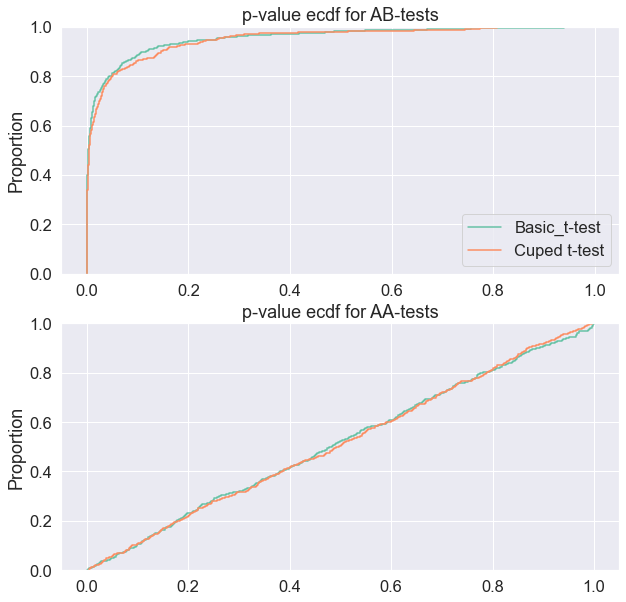

In [600]:
# проверим базовую формулу
# проверим дает ли нам данные размеры выборки гарантируют  нуную мощность 0.8

# оценим мощность двух тестов через симуляцию
basic_pval_list_AB =  []
cuped_pval_list_AB = []
basic_pval_list_AA =  []
cuped_pval_list_AA = []

sim_num = 500
for _ in tqdm(range(sim_num)):
    
    # базовый АБ тест с обычным размером выборки
    df_control_basic = generate_corr_data(basic_sample_size, control_mean, control_mean, corr=pre_post_corr)
    df_test_basic = generate_corr_data(basic_sample_size, control_mean, control_mean*(1+rel_effect), corr=pre_post_corr) # дадим эффект
    basic_ttest_pval = get_basic_ttest(df_control_basic['post_value'], df_test_basic['post_value'])['p_value']
    basic_pval_list_AB.append(basic_ttest_pval)
    
    # CUPED АБ t-test
    df_control_cuped = generate_corr_data(cuped_sample_size, control_mean, control_mean, corr=pre_post_corr)
    df_test_cuped = generate_corr_data(cuped_sample_size, control_mean, control_mean*(1+rel_effect), corr=pre_post_corr) # дадим эффект                                   
    cuped_ttest_pval = get_cuped_ttest(df_control_cuped['pre_value'], df_control_cuped['post_value'], df_test_cuped['pre_value'], df_test_cuped['post_value'])['p_value']
    cuped_pval_list_AB.append(cuped_ttest_pval)
    
    # -----------------------------------------

    # базовый АА тест с обычным размером выборки
    df_control_basic = generate_corr_data(basic_sample_size, control_mean, control_mean, corr=pre_post_corr)
    df_test_basic = generate_corr_data(basic_sample_size, control_mean, control_mean, corr=pre_post_corr) # дадим эффект
    basic_ttest_pval = get_basic_ttest(df_control_basic['post_value'], df_test_basic['post_value'])['p_value']
    basic_pval_list_AA.append(basic_ttest_pval)
    
    # CUPED АА t-test
    df_control_cuped = generate_corr_data(cuped_sample_size, control_mean, control_mean, corr=pre_post_corr)
    df_test_cuped = generate_corr_data(cuped_sample_size, control_mean, control_mean, corr=pre_post_corr) # дадим эффект                                   
    cuped_ttest_pval = get_cuped_ttest(df_control_cuped['pre_value'], df_control_cuped['post_value'], df_test_cuped['pre_value'], df_test_cuped['post_value'])['p_value']
    cuped_pval_list_AA.append(cuped_ttest_pval)
                                       
#оценка мощности    
basic_ttest_power = (np.array(basic_pval_list_AB) < 0.05).sum() / sim_num
cuped_ttest_power = (np.array(cuped_pval_list_AB) < 0.05).sum() / sim_num

#оценка стат.значимости  
basic_tt_alpha = (np.array(basic_pval_list_AA) < 0.05).sum() / sim_num
cuped_ttest_alpha = (np.array(cuped_pval_list_AA) < 0.05).sum() / sim_num

print('Размер выборки для обычного теста И CUPED теста составили: {} и {} соответственно'.format(basic_sample_size, cuped_sample_size))
print('Мощность обычного t-test:', basic_ttest_power)
print('Мощность CUPED t-test', cuped_ttest_power)
print('--------------')
print('Стат значимость обычного t-test:', basic_tt_alpha)
print('Стат значимость CUPED t-test', cuped_ttest_alpha)


# PLOT
fig, axes = plt.subplots(2, figsize=(10,10))
sns.ecdfplot(ax=axes[0], data = basic_pval_list_AB, label = 'Basic_t-test')
sns.ecdfplot(ax=axes[0], data = np.array(cuped_pval_list_AB), label = 'Cuped t-test')
axes[0].set_title('p-value ecdf for AB-tests')
axes[0].legend(loc='lower right')

sns.ecdfplot(ax=axes[1], data = basic_pval_list_AA)
sns.ecdfplot(ax=axes[1], data = np.array(cuped_pval_list_AA))

axes[1].set_title('p-value ecdf for AA-tests')

- Как мы видим на графике выше, оба размера выборки работают корректно. Тесты проведенные на таких размерах выборки показывают нормальную мощность и стат значимость
- При этом размер выборки для CUPED теста получается почти в 2 раза ниже за счет присутсвия корреляции между PRE и POST данными
- Если корреляция во время теста сохранится на том же уровне, что и в исторических данных. То рассчитанного размера выборки хватит для достижения мощности теста
- Но если корреляция снизится, то мощность может пострадать
- Поэтому рекомендую смотреть корреляцию в исторических данных за несколько периодов, чтобы увидить изменчивость этого параметра
- Как оценку параметра корреляции можно брать средний уровень корреляция за период